## Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/traffic.csv")

print(df.head())
print(df.info())

              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


In [ ]:
df["DateTime"] = pd.to_datetime(df["DateTime"])

df["hour"] = df["DateTime"].dt.hour
df["day"] = df["DateTime"].dt.day
df["month"] = df["DateTime"].dt.month
df["weekday"] = df["DateTime"].dt.weekday

df.head()

,DateTime,Junction,Vehicles,ID,hour,day,month,weekday
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11,6
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11,6
2,2015-11-01 02:00:00,1,10,20151101021,2,1,11,6
3,2015-11-01 03:00:00,1,7,20151101031,3,1,11,6
4,2015-11-01 04:00:00,1,9,20151101041,4,1,11,6


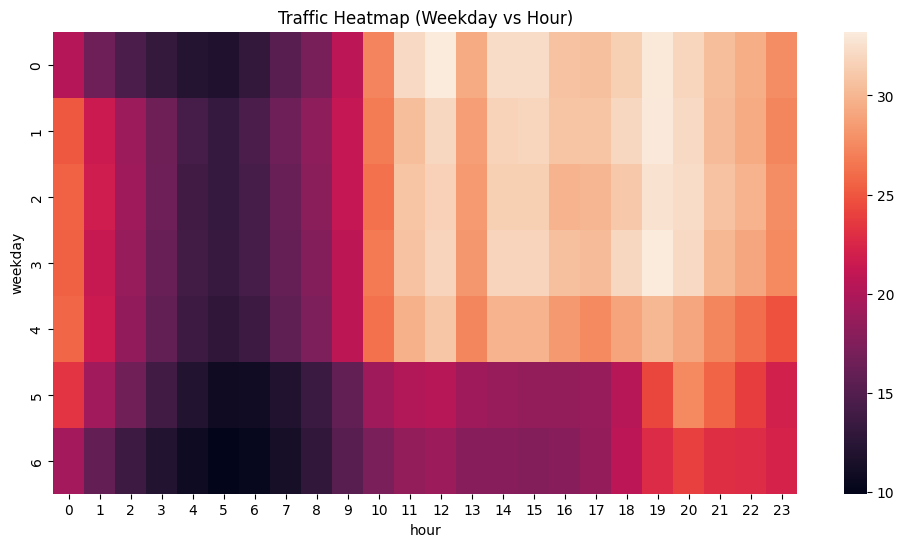

In [ ]:
pivot = df.pivot_table(
    values="Vehicles",
    index="weekday",
    columns="hour",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot)

plt.title("Traffic Heatmap (Weekday vs Hour)")
plt.show()

In [ ]:
X = df[['Junction', 'hour', 'day', 'month', 'weekday']]
y = df['Vehicles']

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVR(kernel='rbf', C=100, epsilon=0.1)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("EXP 1 (Basic)")
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

EXP 1 (Basic)
R2: 0.6691469203115437
RMSE: 11.611980681580556


## Add Lag Features

In [ ]:
df_exp = df.copy()
df_exp = df_exp.sort_values(by=["Junction", "DateTime"])

df_exp["lag_1"] = df_exp.groupby("Junction")["Vehicles"].shift(1)
df_exp["lag_2"] = df_exp.groupby("Junction")["Vehicles"].shift(2)

df_exp = df_exp.dropna()

X = df_exp[['Junction','hour','day','month','weekday','lag_1','lag_2']]
y = df_exp['Vehicles']

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVR(kernel='rbf', C=100, epsilon=0.1)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("EXP 2 (+ Lag)")
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

EXP 2 (+ Lag)
R2: 0.07129697197229246
RMSE: 9.60467002036694


In [ ]:
df_exp2 = df.copy()
df_exp2 = df_exp2.sort_values(by=["Junction", "DateTime"])

df_exp2["lag_1"] = df_exp2.groupby("Junction")["Vehicles"].shift(1)
df_exp2["lag_2"] = df_exp2.groupby("Junction")["Vehicles"].shift(2)
df_exp2["lag_24"] = df_exp2.groupby("Junction")["Vehicles"].shift(24)

df_exp2 = df_exp2.dropna()

X = df_exp2[['Junction','hour','day','month','weekday',
             'lag_1','lag_2','lag_24']]
y = df_exp2['Vehicles']

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVR(kernel='rbf', C=200, epsilon=0.05)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("EXP 3 (+ lag_24)")
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

EXP 3 (+ lag_24)
R2: 0.18993298369681144
RMSE: 8.970795656297305


## Add lag_24 (Daily Pattern)

In [ ]:
df_exp3 = df.copy()
df_exp3 = df_exp3.sort_values(by=["Junction", "DateTime"])

df_exp3["lag_1"] = df_exp3.groupby("Junction")["Vehicles"].shift(1)
df_exp3["lag_2"] = df_exp3.groupby("Junction")["Vehicles"].shift(2)
df_exp3["lag_24"] = df_exp3.groupby("Junction")["Vehicles"].shift(24)

df_exp3["rolling_mean_3"] = df_exp3.groupby("Junction")["Vehicles"].transform(
    lambda x: x.shift(1).rolling(3).mean()
)

df_exp3["rolling_mean_24"] = df_exp3.groupby("Junction")["Vehicles"].transform(
    lambda x: x.shift(1).rolling(24).mean()
)

df_exp3 = df_exp3.dropna()

X = df_exp3[['Junction','hour','day','month','weekday',
             'lag_1','lag_2','lag_24',
             'rolling_mean_3','rolling_mean_24']]
y = df_exp3['Vehicles']

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVR(kernel='rbf', C=300, epsilon=0.05)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("EXP 4 (+ Rolling)")
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

EXP 4 (+ Rolling)
R2: 0.4874210813389911
RMSE: 7.135934577249371


## Add Rolling Mean

In [ ]:
df_exp4 = df.copy()
df_exp4 = df_exp4.sort_values(by=["Junction", "DateTime"])

df_exp4["lag_1"] = df_exp4.groupby("Junction")["Vehicles"].shift(1)
df_exp4["lag_2"] = df_exp4.groupby("Junction")["Vehicles"].shift(2)
df_exp4["lag_24"] = df_exp4.groupby("Junction")["Vehicles"].shift(24)

df_exp4["rolling_mean_3"] = df_exp4.groupby("Junction")["Vehicles"].transform(
    lambda x: x.shift(1).rolling(3).mean()
)

df_exp4["rolling_mean_24"] = df_exp4.groupby("Junction")["Vehicles"].transform(
    lambda x: x.shift(1).rolling(24).mean()
)

df_exp4["is_rush_hour"] = df_exp4["hour"].isin([8,9,17,18,19]).astype(int)
df_exp4["is_weekend"] = (df_exp4["weekday"] >= 5).astype(int)

df_exp4 = df_exp4.dropna()

X = df_exp4[['Junction','hour','day','month','weekday',
             'lag_1','lag_2','lag_24',
             'rolling_mean_3','rolling_mean_24',
             'is_rush_hour','is_weekend']]
y = df_exp4['Vehicles']

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVR(kernel='rbf', C=500, epsilon=0.01)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("FINAL MODEL")
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

FINAL MODEL
R2: 0.5741876532407417
RMSE: 6.503986250149064
MAE: 4.289257603988878


## Add Domain Features

In [ ]:
df_exp4 = df.copy()
df_exp4 = df_exp4.sort_values(by=["Junction", "DateTime"])

df_exp4["lag_1"] = df_exp4.groupby("Junction")["Vehicles"].shift(1)
df_exp4["lag_2"] = df_exp4.groupby("Junction")["Vehicles"].shift(2)
df_exp4["lag_24"] = df_exp4.groupby("Junction")["Vehicles"].shift(24)

df_exp4["rolling_mean_3"] = df_exp4.groupby("Junction")["Vehicles"].transform(
    lambda x: x.shift(1).rolling(3).mean()
)

df_exp4["rolling_mean_24"] = df_exp4.groupby("Junction")["Vehicles"].transform(
    lambda x: x.shift(1).rolling(24).mean()
)

df_exp4["is_rush_hour"] = df_exp4["hour"].isin([8,9,17,18,19]).astype(int)
df_exp4["is_weekend"] = (df_exp4["weekday"] >= 5).astype(int)

df_exp4 = df_exp4.dropna()

X = df_exp4[['Junction','hour','day','month','weekday',
             'lag_1','lag_2','lag_24',
             'rolling_mean_3','rolling_mean_24',
             'is_rush_hour','is_weekend']]
y = df_exp4['Vehicles']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False
)

model = SVR(kernel='rbf', C=500, epsilon=0.01)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("EXP 5 (FINAL)")
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))